Sacar todos los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importamos los algoritmos de clusterizacion a utilizar en esta notebook
from sklearn.cluster import KMeans                    # K-means
from sklearn.cluster import AgglomerativeClustering   # Clustering jerárquico

# Clase para realizar componentes principales
from sklearn.decomposition import PCA

# Estandarizador (transforma las variables en z-scores)
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler() # Creamos el estandarizador

# Paquete de scipy que tiene la clase 'dendograma' que vamos a utilizar
import scipy.cluster.hierarchy as shc

from sklearn.datasets import fetch_olivetti_faces # para cargar el dataset de caras

#from kneed import KneeLocator # importamos el paquete para detectar el codo

# importamos el puntaje de silhouette
from sklearn.metrics import silhouette_score

In [2]:
# Path de nuestro dataset
filename = './Datos/TankTraining_20_11_2025 17_19_31.csv'
filename1 = './Datos/TankTraining_20_11_2025 17_19_58.csv'
filename2 = './Datos/TankTraining_20_11_2025 17_21_10.csv'
filename3 = './Datos/TankTraining_20_11_2025 17_21_42.csv'
filename4 = './Datos/TankTraining_20_11_2025 17_22_02.csv'
filename5 = './Datos/TankTraining_20_11_2025 17_22_28.csv'
filename6 = './Datos/TankTraining_20_11_2025 17_23_04.csv'
filename7 = './Datos/TankTraining_20_11_2025 17_25_35.csv'
filename8 = './Datos/TankTraining_20_11_2025 17_27_43.csv'
filename9 = './Datos/TankTraining_20_11_2025 17_28_33.csv'
filename11 = './Datos/TankTraining_20_11_2025 17_32_19.csv'
filename12 = './Datos/TankTraining_20_11_2025 17_33_26.csv'
filename13 = './Datos/TankTraining_24_11_2025 10_37_21.csv'
filename14 = './Datos/TankTraining_24_11_2025 10_39_37.csv'

# Carga del dataset
df = pd.read_csv(filename)
df1 = pd.read_csv(filename1)
df2 = pd.read_csv(filename2)
df3 = pd.read_csv(filename3)
df4 = pd.read_csv(filename4)
df5 = pd.read_csv(filename5)
df6 = pd.read_csv(filename6)
df7 = pd.read_csv(filename7)
df8 = pd.read_csv(filename8)
df9 = pd.read_csv(filename9)
df11 = pd.read_csv(filename11)
df12 = pd.read_csv(filename12)
df13  = pd.read_csv(filename13) 
df14 = pd.read_csv(filename14) 
# Inspecciono las primeras filas
df.head()

,NEIGHBORHOOD_UP,NEIGHBORHOOD_DOWN,NEIGHBORHOOD_RIGHT,NEIGHBORHOOD_LEFT,NEIGHBORHOOD_DIST_UP,NEIGHBORHOOD_DIST_DOWN,NEIGHBORHOOD_DIST_RIGHT,NEIGHBORHOOD_DIST_LEFT,COMMAND_CENTER_X,COMMAND_CENTER_Y,...,AGENT_2_X,AGENT_2_Y,CAN_FIRE,HEALTH,LIFE_X,LIFE_Y,EXIT_X,EXIT_Y,time,action
0,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,3.0,27.0,1.0,2.0,11.0,17.0,15.0,25.0,0.156900,0.0
1,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,3.0,27.0,1.0,2.0,11.0,17.0,15.0,25.0,0.224374,0.0
2,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,3.0,27.0,1.0,2.0,11.0,17.0,15.0,25.0,0.302928,0.0
3,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,3.0,27.0,1.0,2.0,11.0,17.0,15.0,25.0,0.409805,0.0
4,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,3.0,27.0,1.0,2.0,11.0,17.0,15.0,25.0,0.503152,0.0


In [3]:
print("Dimensiones del dataset:",df.shape)

Dimensiones del dataset: (129, 22)


Vamos a agrupar los datos utiizando dos features del dataset: el tiempo y la accion

In [4]:
# Me armo una matriz con las ultimas dos columnas del dataframe
sdata = df.iloc[:-1,20:22].values
sdata1 = df1.iloc[:-1,20:22].values
sdata2 = df2.iloc[:-1,20:22].values
sdata3 = df3.iloc[:-1,20:22].values
sdata4 = df4.iloc[:-1,20:22].values
sdata5 = df5.iloc[:-1,20:22].values
sdata6 = df6.iloc[:-1,20:22].values
sdata7 = df7.iloc[:-1,20:22].values
sdata8 = df8.iloc[:-1,20:22].values
sdata9 = df9.iloc[:-1,20:22].values
sdata11 = df11.iloc[:-1,20:22].values
sdata12 = df12.iloc[:-1,20:22].values
sdata13 = df13.iloc[:-1,20:22].values
sdata14 = df14.iloc[:-1,20:22].values

sdata[:5]

array([[0.1568998, 0.       ],
       [0.2243744, 0.       ],
       [0.3029277, 0.       ],
       [0.4098049, 0.       ],
       [0.5031519, 0.       ]])

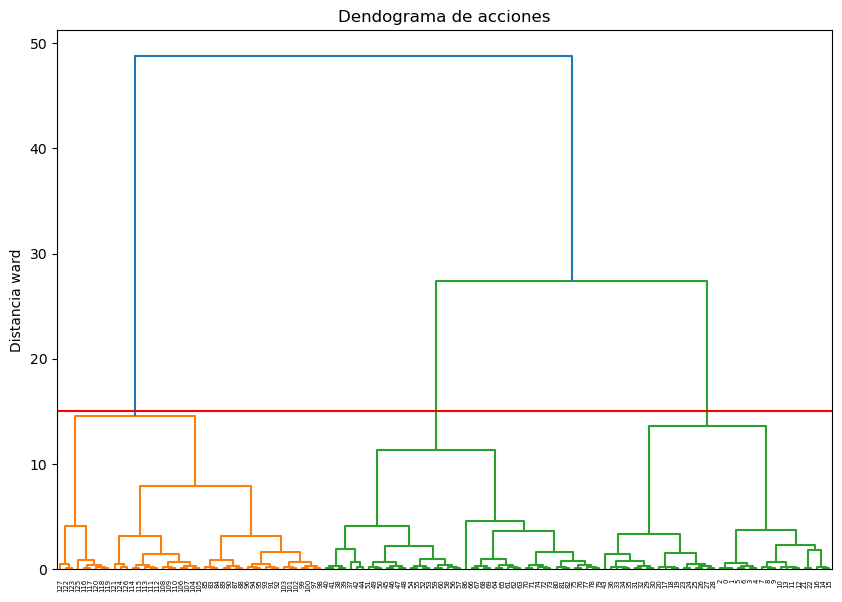

In [5]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend = shc.dendrogram(shc.linkage(sdata, method='ward'))
plt.axhline(15, c='r')

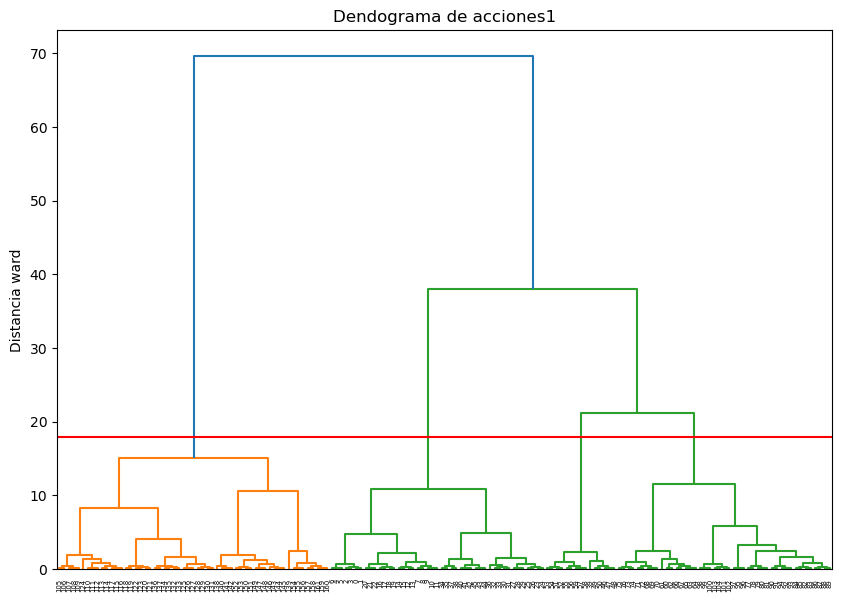

In [6]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones1")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend1 = shc.dendrogram(shc.linkage(sdata1, method='ward'))
plt.axhline(18, c='r')

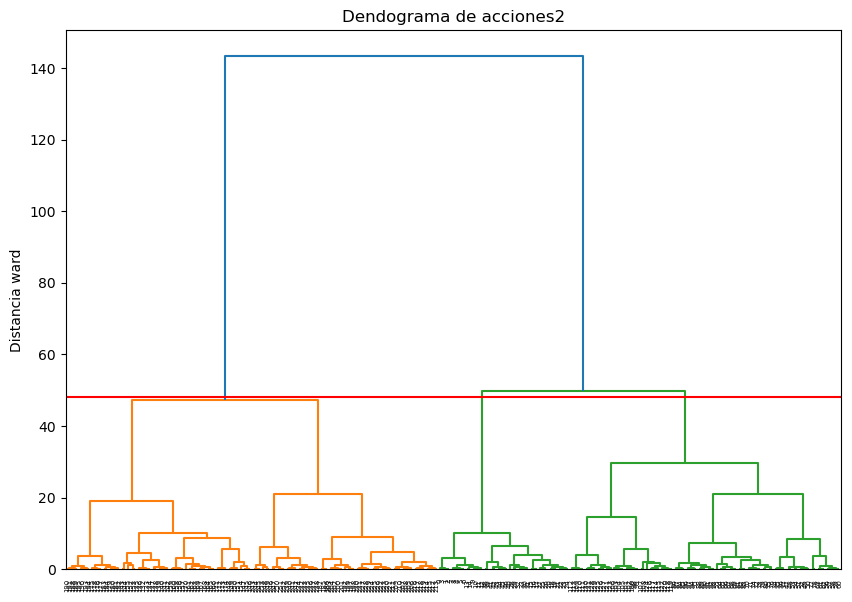

In [7]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones2")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend2 = shc.dendrogram(shc.linkage(sdata2, method='ward'))
plt.axhline(48, c='r')

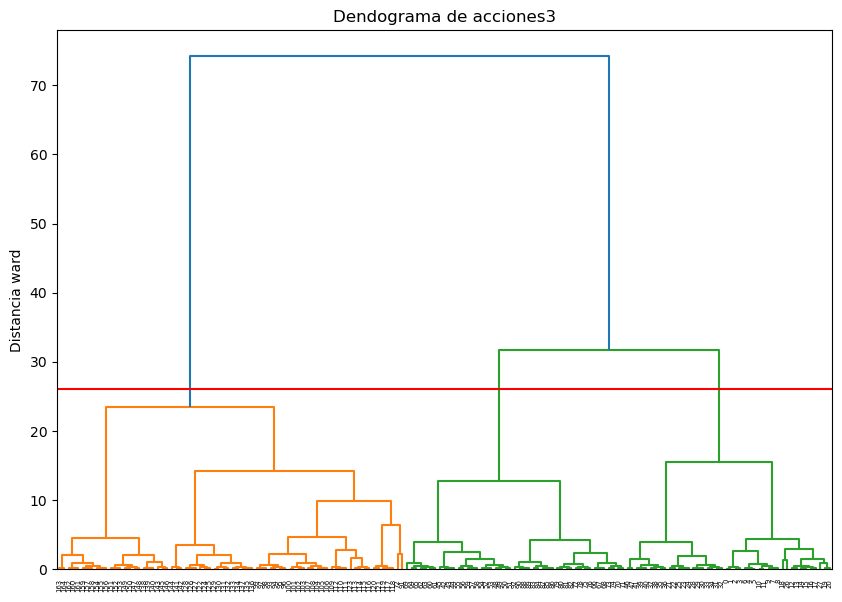

In [8]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones3")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend3 = shc.dendrogram(shc.linkage(sdata3, method='ward'))
plt.axhline(26, c='r')

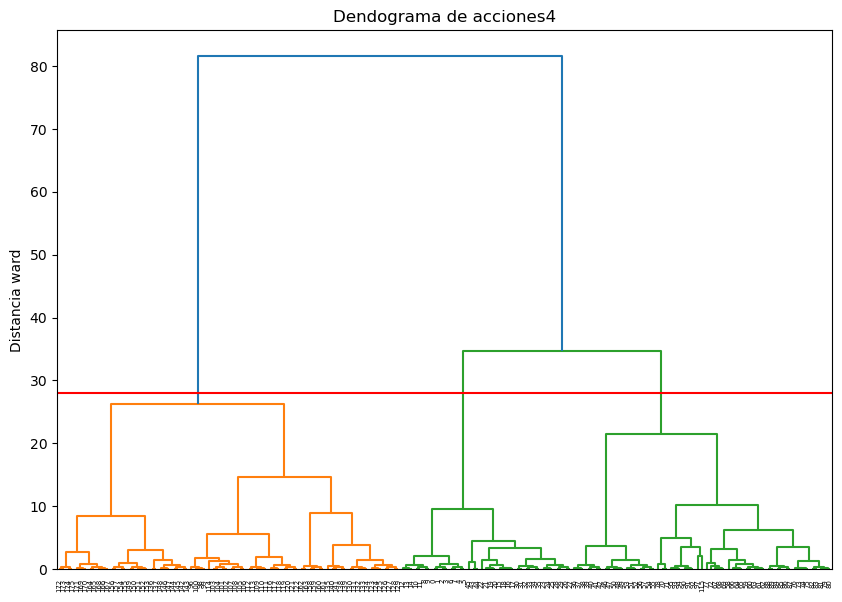

In [9]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones4")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend4 = shc.dendrogram(shc.linkage(sdata4, method='ward'))
plt.axhline(28, c='r')

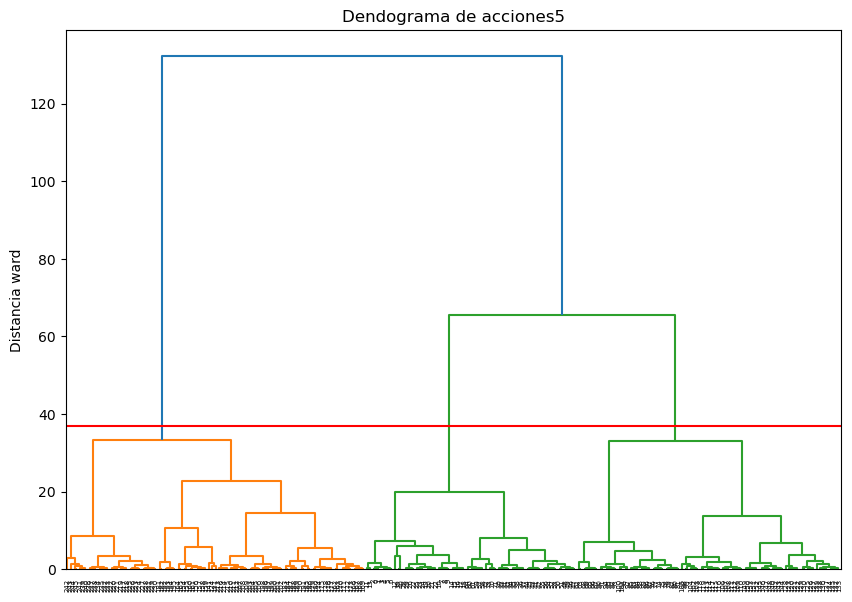

In [10]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones5")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend5 = shc.dendrogram(shc.linkage(sdata5, method='ward'))
plt.axhline(37, c='r')

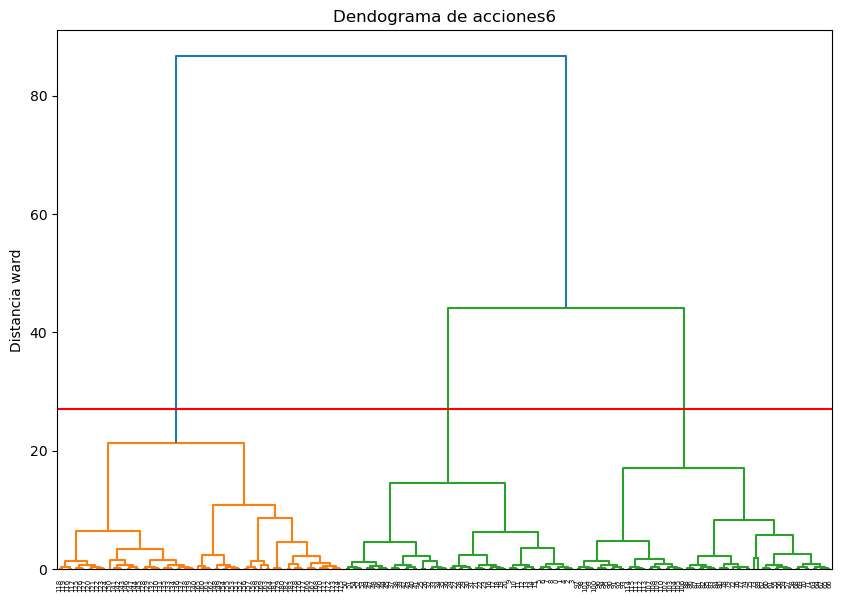

In [11]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones6")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend6 = shc.dendrogram(shc.linkage(sdata6, method='ward'))
plt.axhline(27, c='r')

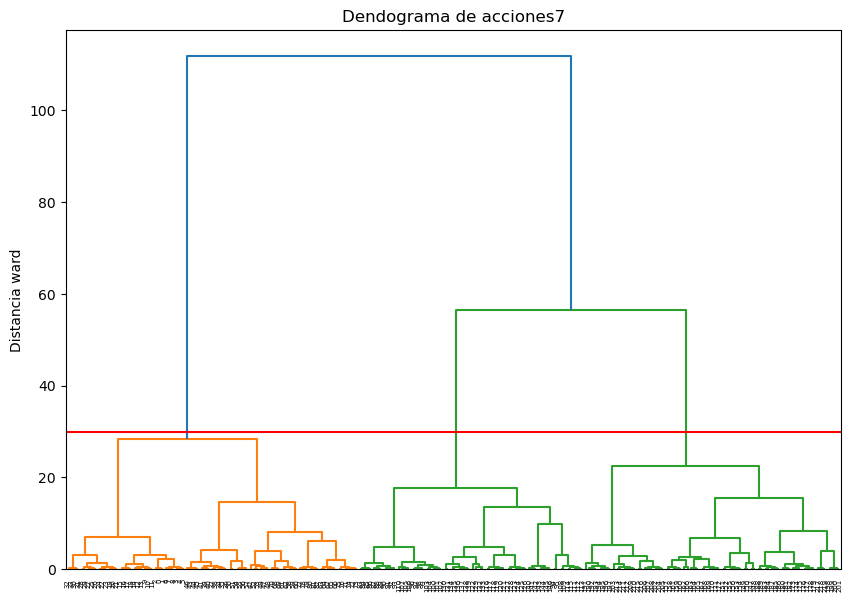

In [12]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones7")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend7 = shc.dendrogram(shc.linkage(sdata7, method='ward'))
plt.axhline(30, c='r')

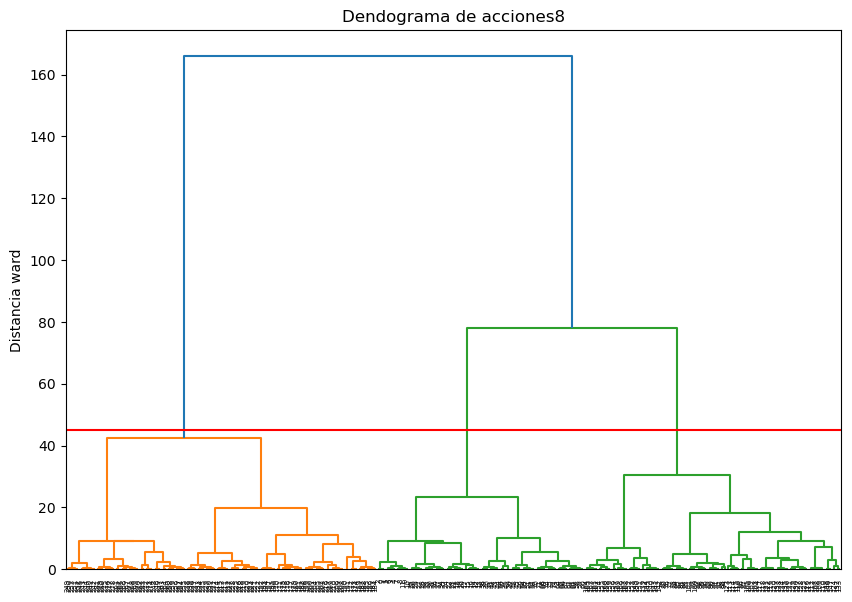

In [13]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones8")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend8 = shc.dendrogram(shc.linkage(sdata8, method='ward'))
plt.axhline(45, c='r')

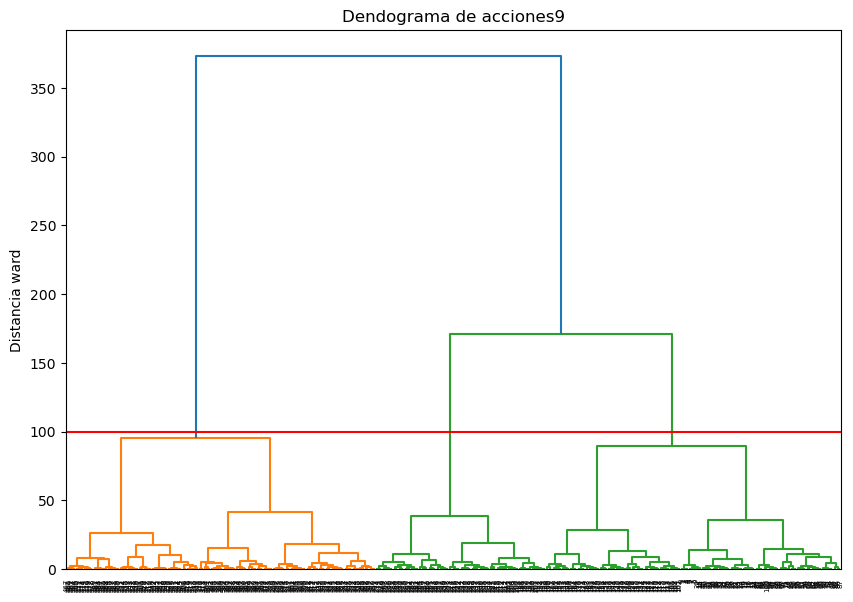

In [14]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones9")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend9 = shc.dendrogram(shc.linkage(sdata9, method='ward'))
plt.axhline(100, c='r')

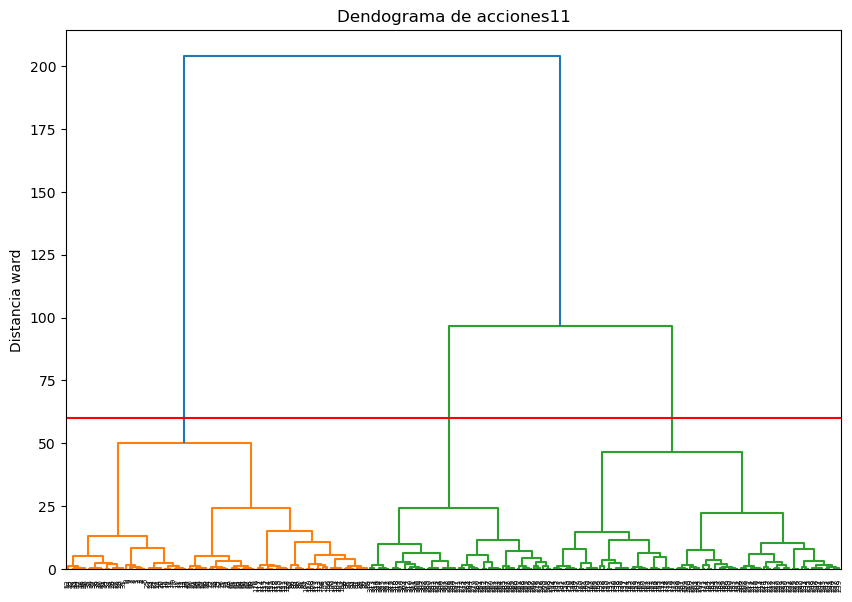

In [15]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones11")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend11 = shc.dendrogram(shc.linkage(sdata11, method='ward'))
plt.axhline(60, c='r')

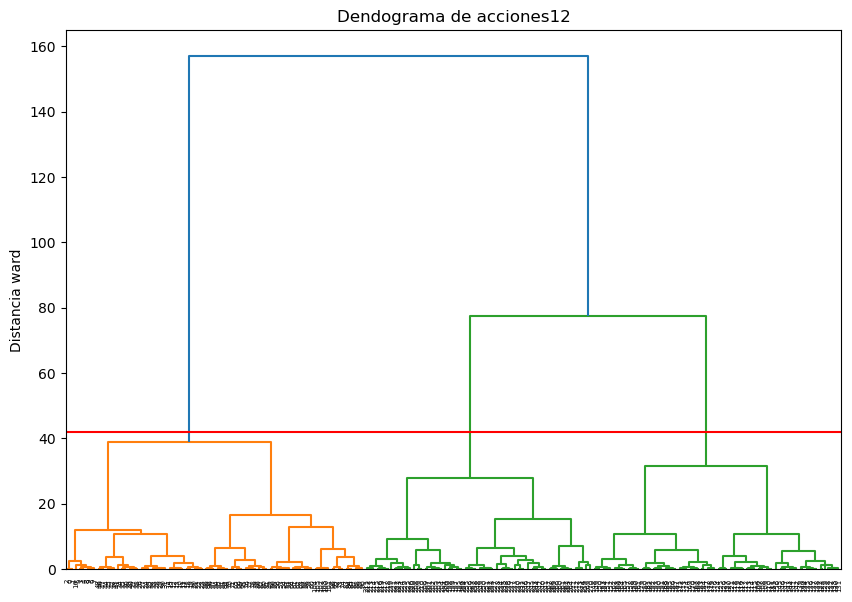

In [16]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones12")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend12 = shc.dendrogram(shc.linkage(sdata12, method='ward'))
plt.axhline(42, c='r')

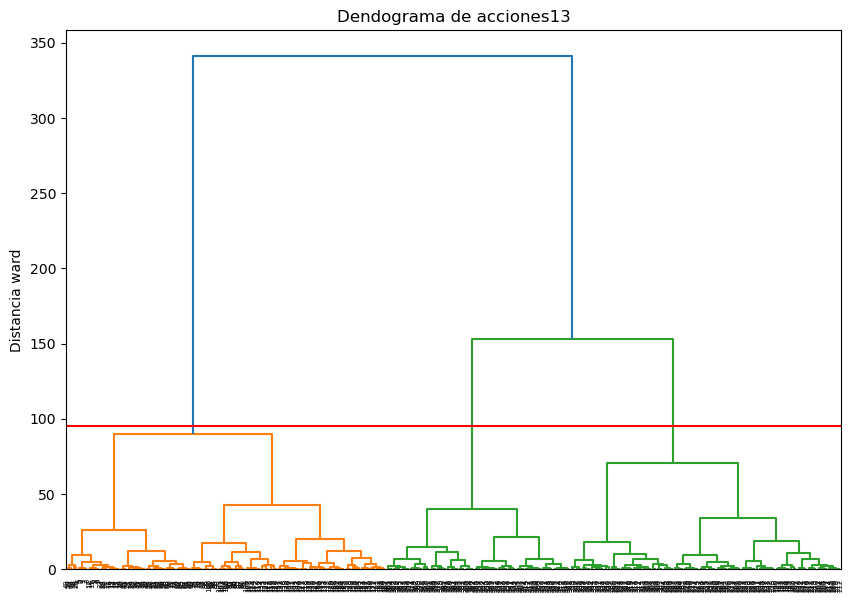

In [17]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones13")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend13 = shc.dendrogram(shc.linkage(sdata13, method='ward'))
plt.axhline(95, c='r')

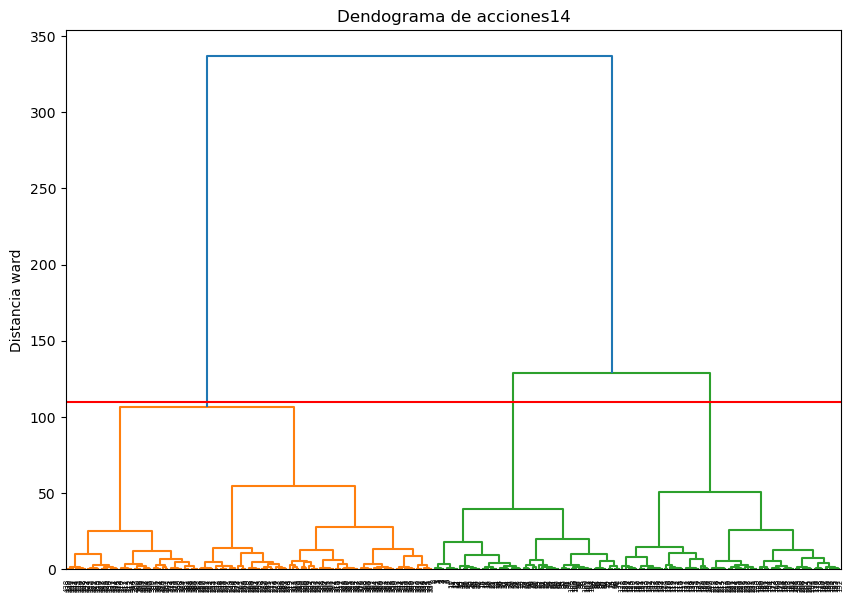

In [18]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones14")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend14 = shc.dendrogram(shc.linkage(sdata14, method='ward'))
plt.axhline(110, c='r')

Creamos los clusters con n_clusters siendo la cantidad de lineas verticales que pasan por la horizontal 

In [19]:
# Importo el método de clustering jerárquico (bottom-up)
from sklearn.cluster import AgglomerativeClustering

In [20]:
# Creamos el modelo
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster.fit_predict(sdata)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

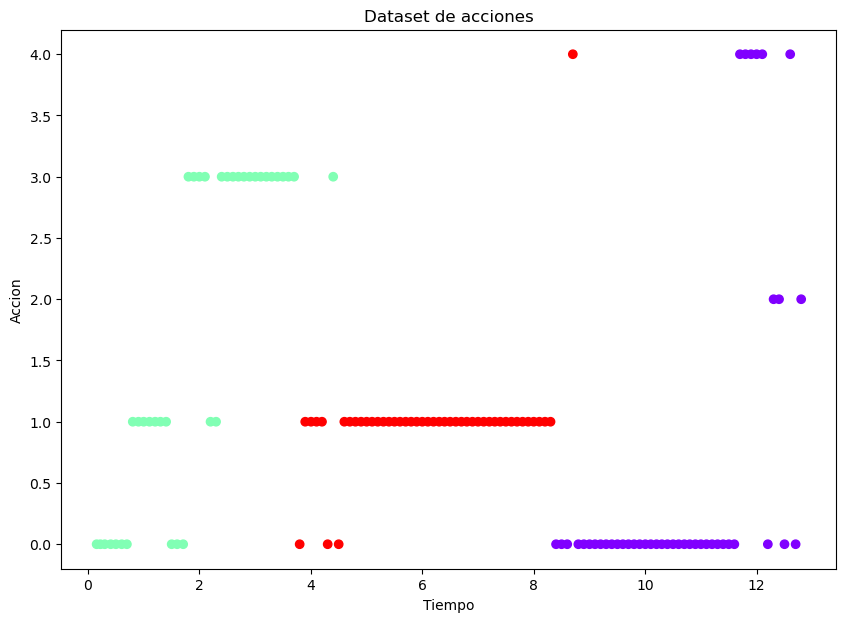

In [21]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones")
plt.scatter(sdata[:,0], sdata[:,1], c=cluster.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [22]:
# Creamos el modelo
cluster1 = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Lo ajustamos con los datos
cluster1.fit_predict(sdata1)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

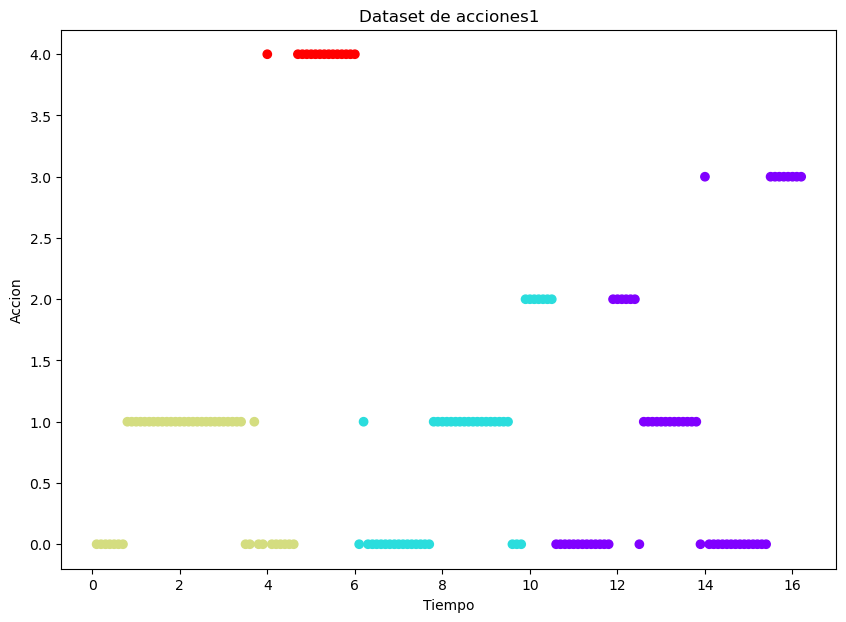

In [23]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones1")
plt.scatter(sdata1[:,0], sdata1[:,1], c=cluster1.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [24]:
# Creamos el modelo
cluster2 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster2.fit_predict(sdata2)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

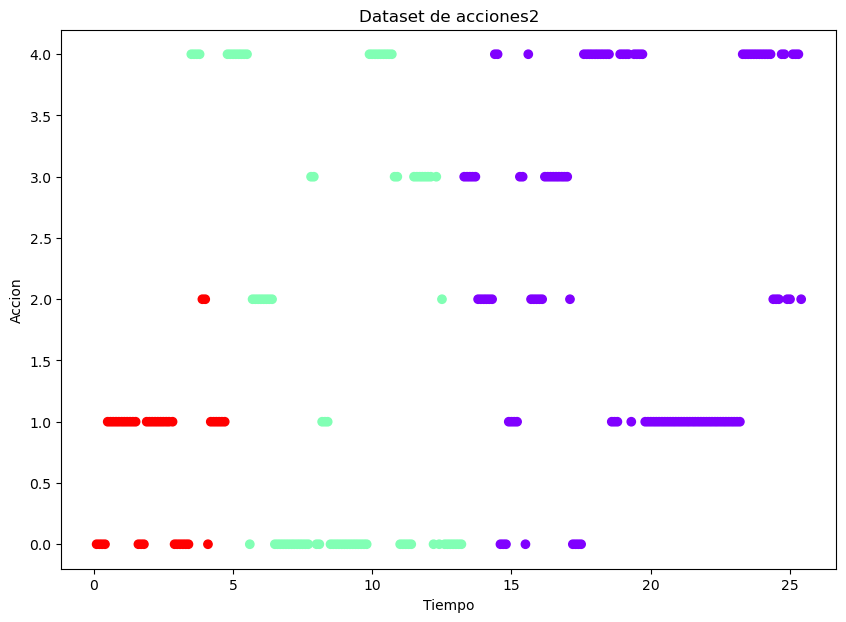

In [25]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones2")
plt.scatter(sdata2[:,0], sdata2[:,1], c=cluster2.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [26]:
# Creamos el modelo
cluster3 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster3.fit_predict(sdata3)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

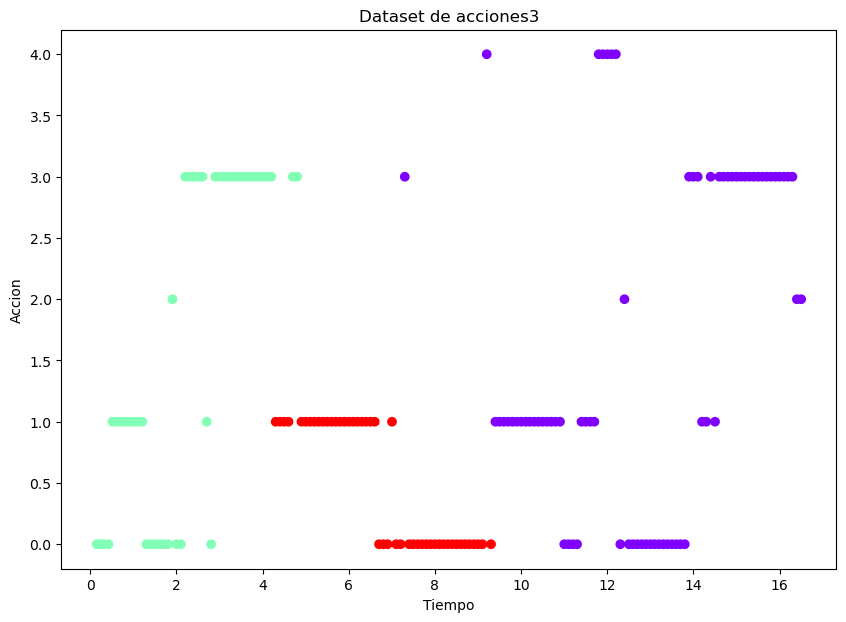

In [27]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones3")
plt.scatter(sdata3[:,0], sdata3[:,1], c=cluster3.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [28]:
# Creamos el modelo
cluster4 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster4.fit_predict(sdata4)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

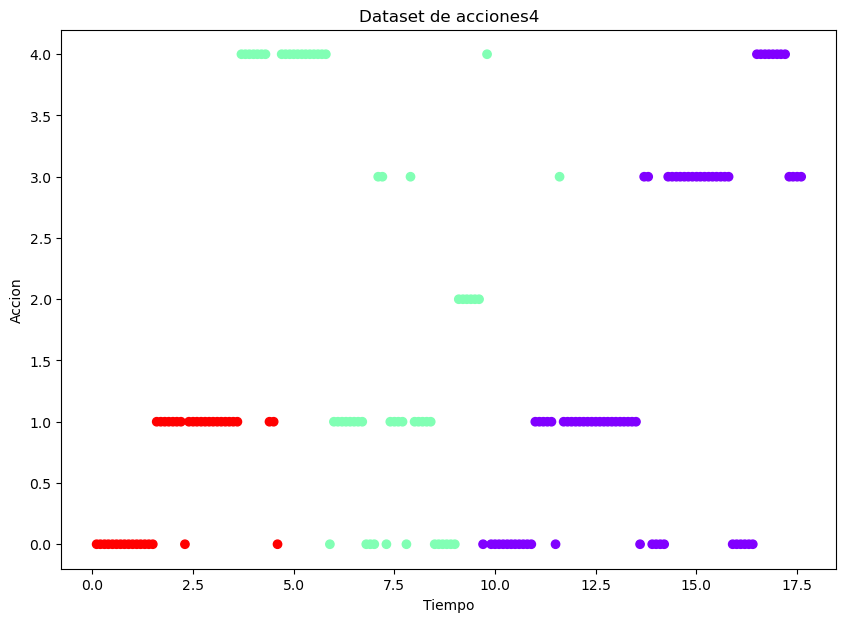

In [29]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones4")
plt.scatter(sdata4[:,0], sdata4[:,1], c=cluster4.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [30]:
# Creamos el modelo
cluster5 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster5.fit_predict(sdata5)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

Text(0, 0.5, 'Accion')

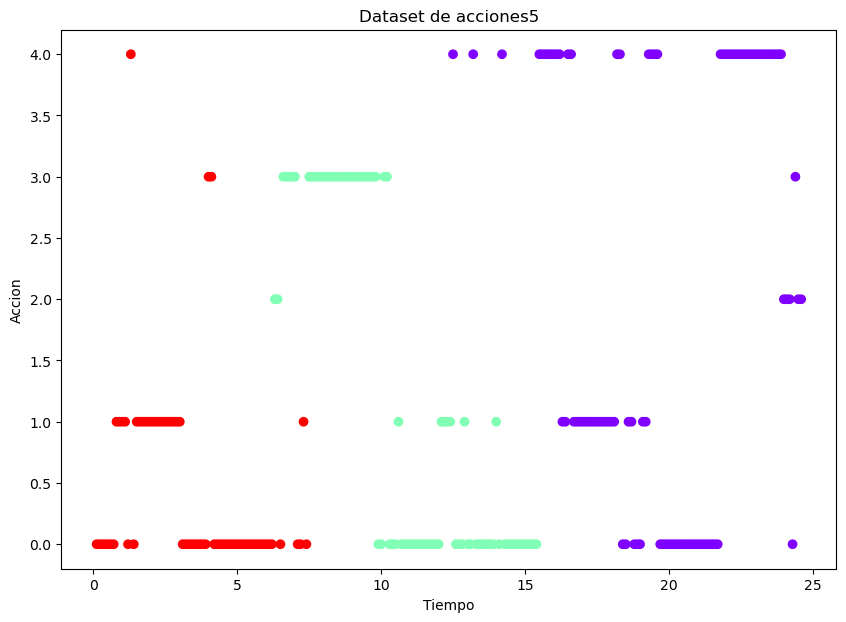

In [31]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones5")
plt.scatter(sdata5[:,0], sdata5[:,1], c=cluster5.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [32]:
# Creamos el modelo
cluster6 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster6.fit_predict(sdata6)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

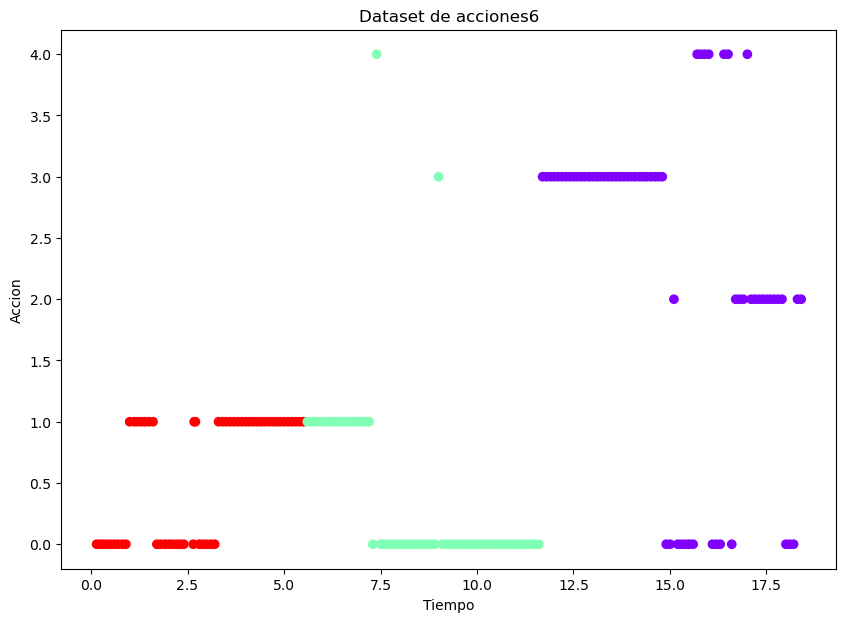

In [33]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones6")
plt.scatter(sdata6[:,0], sdata6[:,1], c=cluster6.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [34]:
# Creamos el modelo
cluster7 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster7.fit_predict(sdata7)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Text(0, 0.5, 'Accion')

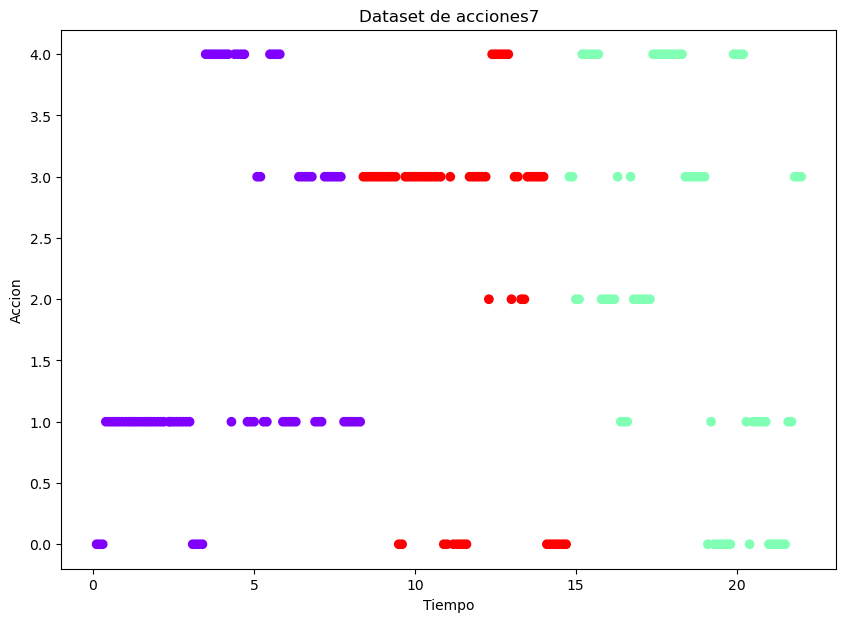

In [35]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones7")
plt.scatter(sdata7[:,0], sdata7[:,1], c=cluster7.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [36]:
# Creamos el modelo
cluster8 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster8.fit_predict(sdata8)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0, 0.5, 'Accion')

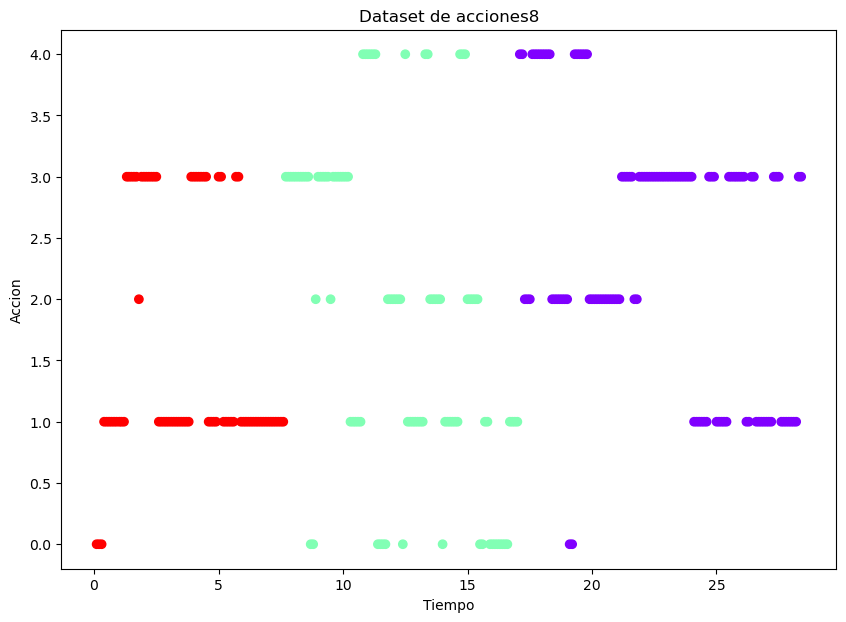

In [37]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones8")
plt.scatter(sdata8[:,0], sdata8[:,1], c=cluster8.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [38]:
# Creamos el modelo
cluster9 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster9.fit_predict(sdata9)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,

Text(0, 0.5, 'Accion')

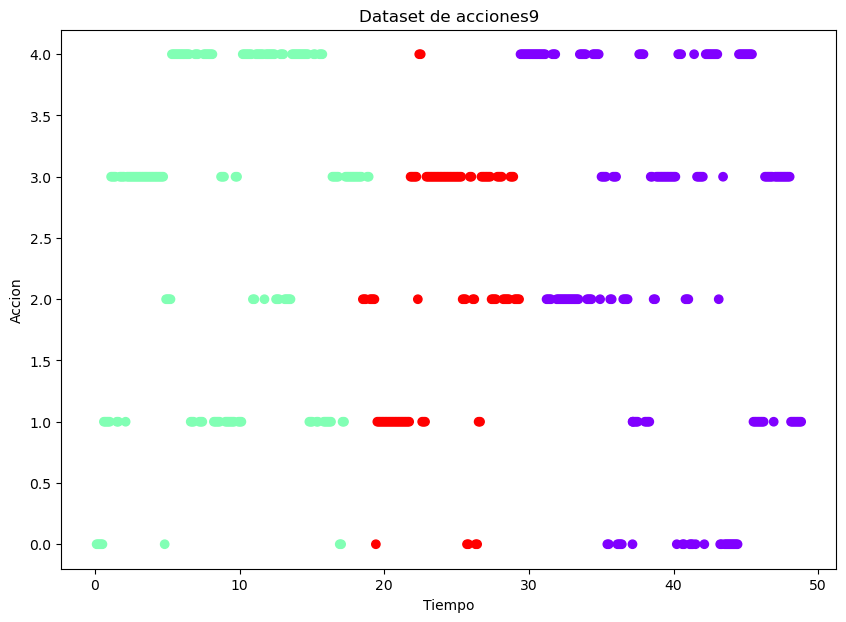

In [39]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones9")
plt.scatter(sdata9[:,0], sdata9[:,1], c=cluster9.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [40]:
# Creamos el modelo
cluster11 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster11.fit_predict(sdata11)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

Text(0, 0.5, 'Accion')

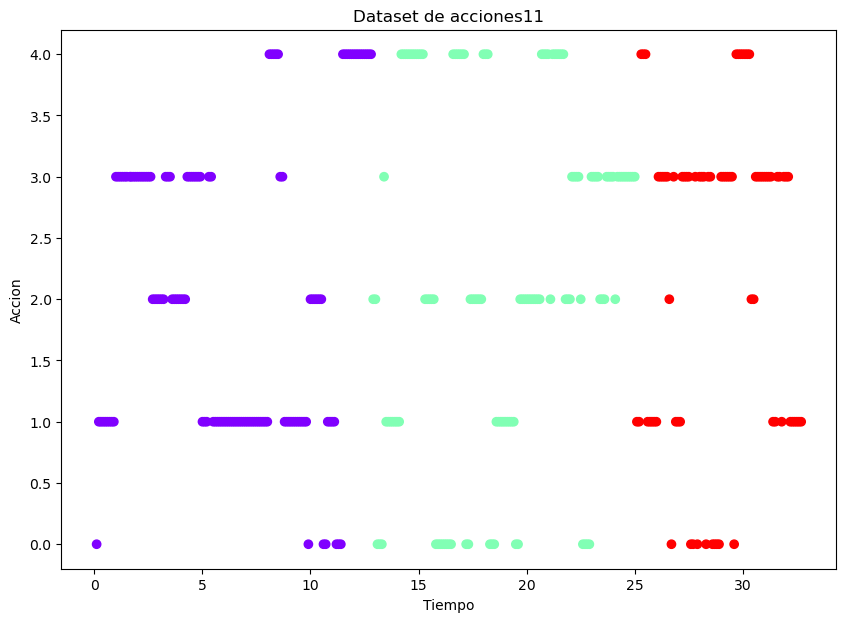

In [41]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones11")
plt.scatter(sdata11[:,0], sdata11[:,1], c=cluster11.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [42]:
# Creamos el modelo
cluster12 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster12.fit_predict(sdata12)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Text(0, 0.5, 'Accion')

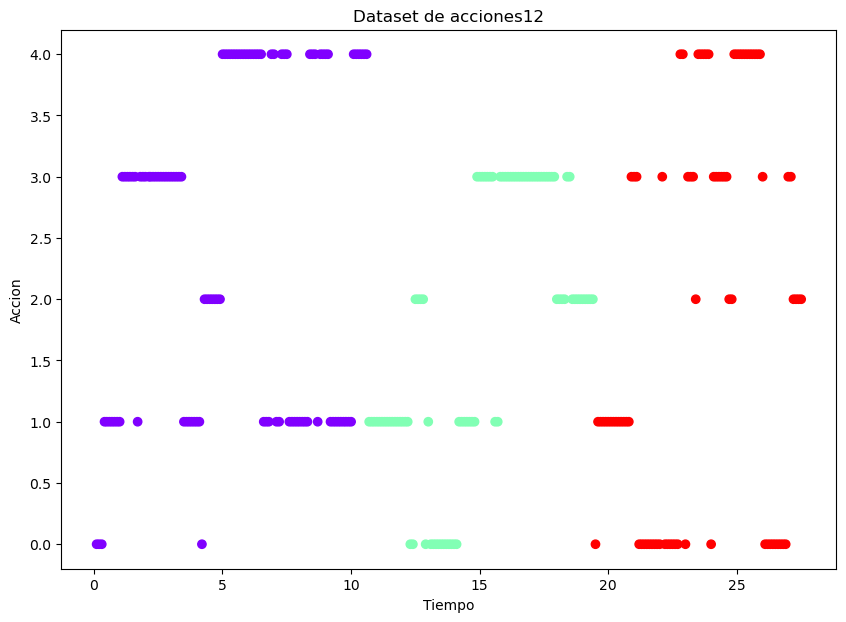

In [43]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones12")
plt.scatter(sdata12[:,0], sdata12[:,1], c=cluster12.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [44]:
# Creamos el modelo
cluster13 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster13.fit_predict(sdata13)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Text(0, 0.5, 'Accion')

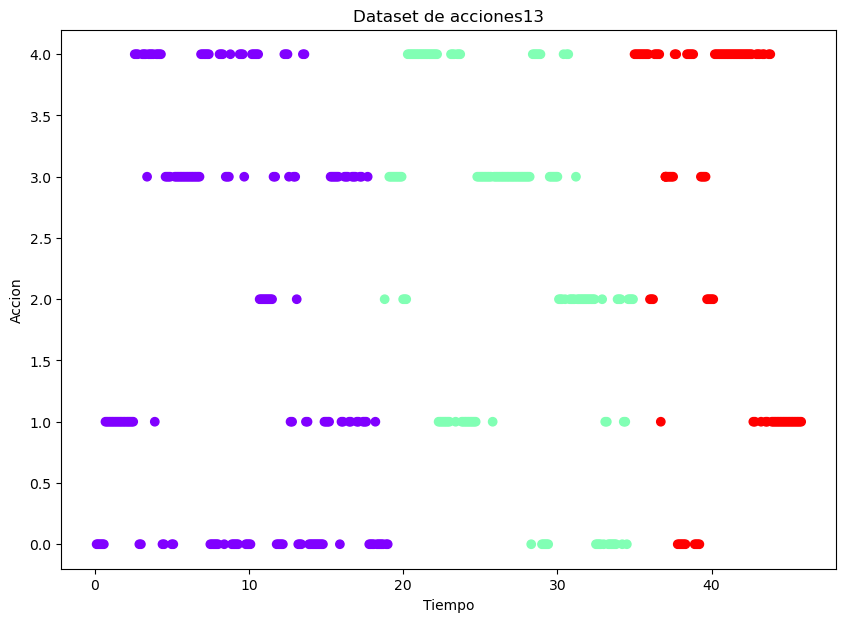

In [45]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones13")
plt.scatter(sdata13[:,0], sdata13[:,1], c=cluster13.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

In [46]:
# Creamos el modelo
cluster14 = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Lo ajustamos con los datos
cluster14.fit_predict(sdata14)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Text(0, 0.5, 'Accion')

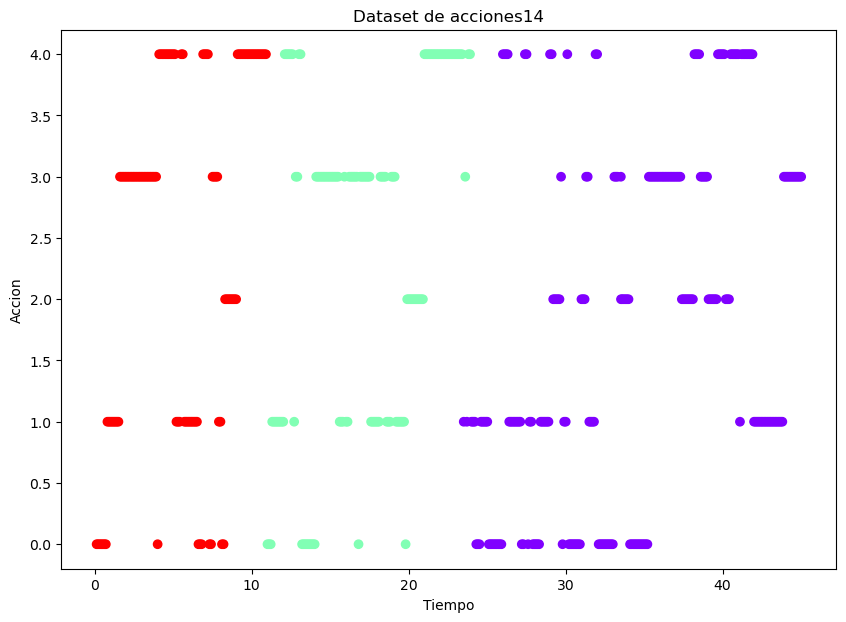

In [47]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones14")
plt.scatter(sdata14[:,0], sdata14[:,1], c=cluster14.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")

Ahora vamos a sacar los datos de un dataset que sea la mezcla de todas las pruebas anteriores

In [48]:
filenameTodo = './Datos/TodosJuntos.csv'
dfTodo = pd.read_csv(filenameTodo)

# Inspecciono las primeras filas
dfTodo.head()

,NEIGHBORHOOD_UP,NEIGHBORHOOD_DOWN,NEIGHBORHOOD_RIGHT,NEIGHBORHOOD_LEFT,NEIGHBORHOOD_DIST_UP,NEIGHBORHOOD_DIST_DOWN,NEIGHBORHOOD_DIST_RIGHT,NEIGHBORHOOD_DIST_LEFT,COMMAND_CENTER_X,COMMAND_CENTER_Y,...,AGENT_2_X,AGENT_2_Y,CAN_FIRE,HEALTH,LIFE_X,LIFE_Y,EXIT_X,EXIT_Y,time,action
0,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,11,17,15,25,0.156900,0
1,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,11,17,15,25,0.224374,0
2,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,11,17,15,25,0.302928,0
3,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,11,17,15,25,0.409805,0
4,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,11,17,15,25,0.503152,0


In [49]:
print("Dimensiones del dataset:",dfTodo.shape)

Dimensiones del dataset: (3817, 22)


In [50]:
sdataTodo = dfTodo.iloc[:,20:22].values

sdataTodo[:5]

array([[0.1568998, 0.       ],
       [0.2243744, 0.       ],
       [0.3029277, 0.       ],
       [0.4098049, 0.       ],
       [0.5031519, 0.       ]])

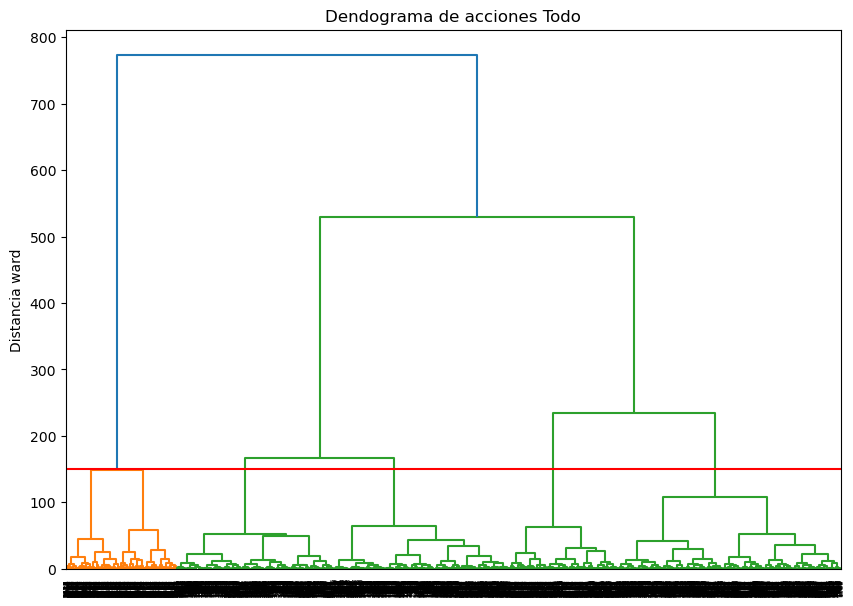

In [51]:
# Plot del dendograma del dataset de clientes
plt.figure(figsize=(10, 7))
plt.title("Dendograma de acciones Todo")
plt.ylabel("Distancia ward")

# Con la función 'dendogram' graficamos el dendograma. 
# El input de esta función es la función 'linkage' donde se especifica la distancia para utlizar en cada paso del método
dend = shc.dendrogram(shc.linkage(sdataTodo, method='ward'))
plt.axhline(150, c='r')

In [52]:
# Creamos el modelo
clusterTodo = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Lo ajustamos con los datos
clusterTodo.fit_predict(sdataTodo)  # fit_predict hace lo mismo que fit pero devuelve el vector de etiquetas de las samples

array([1, 1, 1, ..., 0, 0, 0])

Text(0, 0.5, 'Accion')

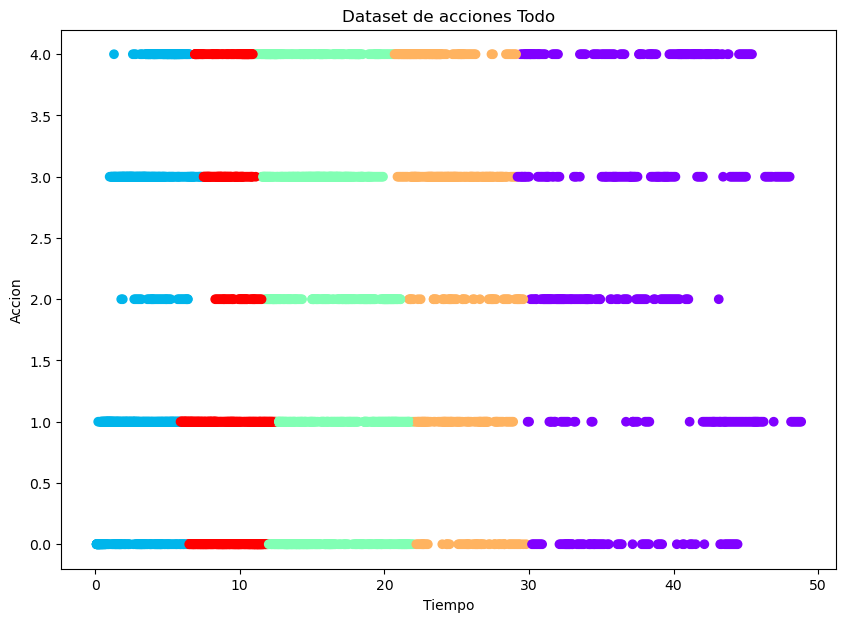

In [53]:
# Ploteamos los datos en el espacio de (Ingresos,Gastos) con un color por cada uno de los 5 clusters
plt.figure(figsize=(10, 7))
plt.title("Dataset de acciones Todo")
plt.scatter(sdataTodo[:,0], sdataTodo[:,1], c=clusterTodo.labels_, cmap='rainbow')
plt.xlabel("Tiempo")
plt.ylabel("Accion")